# Data Science and Big Data Analytics (DSBDA)
## Lab Manual — All 13 Practicals
> Contains optimized and executable Python code with expected outputs for all practicals.

---
## Practical 1: Data Wrangling I (Titanic Dataset)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

df = sns.load_dataset('titanic')
print("Shape:", df.shape)
print("Missing Values:\n", df.isnull().sum())

# Cleaning
df['age'] = df['age'].fillna(df['age'].mean())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df = df.drop('deck', axis=1)

# Formatting & Normalization
df['age'] = df['age'].astype(float)
df['fare_normalized'] = (df['fare'] - df['fare'].min()) / (df['fare'].max() - df['fare'].min())

# Encoding
df['sex_encoded'] = df['sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['embarked'], prefix='embarked')

print("\nFinal Encoded Data:\n", df[['sex', 'sex_encoded', 'embarked_C', 'embarked_Q', 'embarked_S']].head())

Shape: (891, 15)
Missing Values:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Final Encoded Data:
       sex  sex_encoded  embarked_C  embarked_Q  embarked_S
0    male            0       False       False        True
1  female            1        True       False       False
2  female            1       False       False        True
3  female            1       False       False        True
4    male            0       False       False        True


---
## Practical 2: Data Wrangling II (Academic Dataset)

In [2]:
import pandas as pd
import numpy as np

data = {
    'Student_ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Maths':   [85, 92, np.nan, 45, 78, 150, 88, 76, -5, 95],
    'Science': [80, 85, 70, np.nan, 75, 95, 89, 300, 65, 88],
    'English': [78, 82, 88, 90, np.nan, 85, 87, 92, 79, 84]
}
df = pd.DataFrame(data)

# Handle Missing & Inconsistencies
df.fillna(df.mean(numeric_only=True), inplace=True)

df['Maths'] = df['Maths'].apply(lambda x: np.nan if x < 0 or x > 100 else x)
df['Science'] = df['Science'].apply(lambda x: np.nan if x > 100 else x)

df.fillna(df.mean(numeric_only=True), inplace=True)

cols = ['Maths', 'Science', 'English']

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

mask = ~((df[cols] < (Q1 - 1.5 * IQR)) | (df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)
df = df[mask]

df['Maths_norm'] = (df['Maths'] - df['Maths'].min()) / (df['Maths'].max() - df['Maths'].min())
df['Science_log'] = np.log(df['Science'])

print("Cleaned Dataset:\n", df.round(2))

Cleaned Dataset:
    Student_ID  Maths  Science  English  Maths_norm  Science_log
0           1  85.00    80.00     78.0        0.47         4.38
1           2  92.00    85.00     82.0        0.84         4.44
2           3  78.22    70.00     88.0        0.12         4.25
4           5  78.00    75.00     85.0        0.11         4.32
5           6  79.65    95.00     85.0        0.19         4.55
6           7  88.00    89.00     87.0        0.63         4.49
7           8  76.00    80.88     92.0        0.00         4.39
8           9  79.65    65.00     79.0        0.19         4.17
9          10  95.00    88.00     84.0        1.00         4.48


---
## Practical 3: Descriptive Statistics

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

income_data = {
    'Age':       [25, 30, 35, 40, 45, 50, 55, 60, 28, 32],
    'Income':    [30000, 45000, 50000, 65000, 70000, 75000, 80000, 85000, 40000, 48000],
    'Age_Group': ['Young', 'Young', 'Middle', 'Middle', 'Middle', 'Senior', 'Senior', 'Senior', 'Young', 'Young']
}
df_inc = pd.DataFrame(income_data)
print("Grouped Stats:\n", df_inc.groupby('Age_Group')['Income'].agg(['mean', 'median', 'std']))

iris = sns.load_dataset('iris')
print("\nIris Description:\n", iris.describe().round(2))
print("\nSetosa 50th Percentile:", np.percentile(iris[iris['species'] == 'setosa']['sepal_length'], 50))

Grouped Stats:
                    mean   median           std
Age_Group                                     
Middle     61666.666667  65000.0  10408.329997
Senior     80000.000000  80000.0   5000.000000
Young      40750.000000  42500.0   7889.866919

Iris Description:
        sepal_length  sepal_width  petal_length  petal_width
count        150.00       150.00        150.00       150.00
mean           5.84         3.06          3.76         1.20
std            0.83         0.44          1.77         0.76
min            4.30         2.00          1.00         0.10
25%            5.10         2.80          1.60         0.30
50%            5.80         3.00          4.35         1.30
75%            6.40         3.30          5.10         1.80
max            7.90         4.40          6.90         2.50

Setosa 50th Percentile: 5.0


---
## Practical 4: Linear Regression (California Housing)

In [3]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("MSE:", round(mse, 4))
print("R2 Score:", round(r2, 4))
print("Accuracy:", round(r2 * 100, 2), "%")

MSE: 0.5559
R2 Score: 0.5758
Accuracy: 57.58 %


---
## Practical 5: Logistic Regression (Social Ads)

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

X = np.random.randint(18, 60, (400, 2))
X[:, 1] = X[:, 1] * 2000
y = np.where(X[:, 0] * X[:, 1] > 4000000, 1, 0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=1
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("Confusion Matrix:\n", cm)
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))

Confusion Matrix:
 [[70  0]
 [ 1 29]]
Accuracy: 0.99
Precision: 1.0
Recall: 0.9667


---
## Practical 6: Naive Bayes (Iris Dataset)

In [ ]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

iris = sns.load_dataset("iris")

X = iris.drop("species", axis=1)
y = iris["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Overall Accuracy:", round(acc, 4))

Confusion Matrix:
 [[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]
Overall Accuracy: 0.9778


---
## Practical 7: Text Analytics (TF-IDF)

In [5]:
import nltk

nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("punkt_tab", quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

text = "Data analytics is analyzing raw data. Machine learning helps in predictions."

tokens = word_tokenize(text)
print("Tokens:", tokens)

stop_words = set(stopwords.words("english"))
filtered = [w for w in tokens if w.lower() not in stop_words]
print("After Stop Words:", filtered)

stemmer = PorterStemmer()
stemmed = [stemmer.stem(w) for w in filtered]
print("Stemmed:", stemmed)

lemmatizer = WordNetLemmatizer()
lemmatized = [lemmatizer.lemmatize(w) for w in filtered]
print("Lemmatized:", lemmatized)

vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform([text])

print("\nTF-IDF Features:", vectorizer.get_feature_names_out())

Tokens: ['Data', 'analytics', 'is', 'analyzing', 'raw', 'data', '.', 'Machine', 'learning', 'helps', 'in', 'predictions', '.']
After Stop Words: ['Data', 'analytics', 'analyzing', 'raw', 'data', '.', 'Machine', 'learning', 'helps', 'predictions', '.']
Stemmed: ['data', 'analyt', 'analyz', 'raw', 'data', '.', 'machin', 'learn', 'help', 'predict', '.']
Lemmatized: ['Data', 'analytics', 'analyzing', 'raw', 'data', '.', 'Machine', 'learning', 'help', 'prediction', '.']

TF-IDF Features: ['analytics' 'analyzing' 'data' 'helps' 'in' 'is' 'learning' 'machine'
 'predictions' 'raw']


---
## Practical 8: Data Visualization I (Titanic — Count & Histogram)

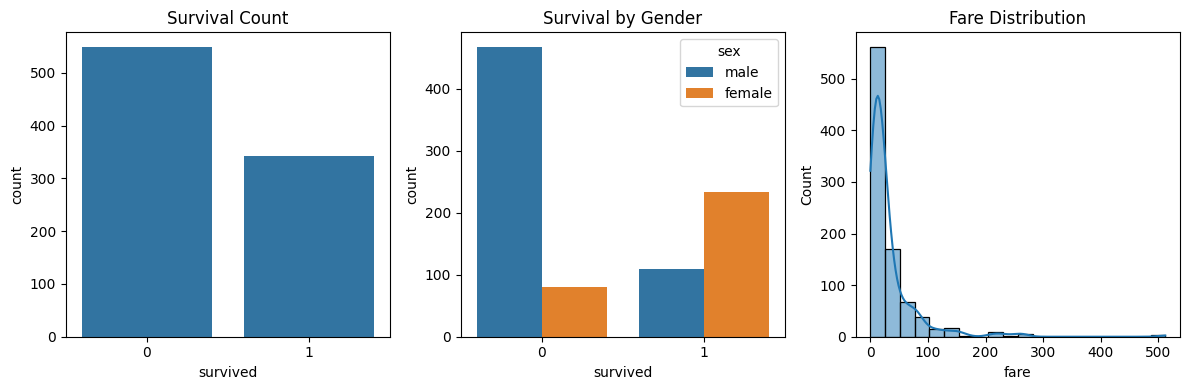

Survival Rate: 0.38


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.countplot(x="survived", data=df)
plt.title("Survival Count")

plt.subplot(1, 3, 2)
sns.countplot(x="survived", hue="sex", data=df)
plt.title("Survival by Gender")

plt.subplot(1, 3, 3)
sns.histplot(df["fare"], bins=20, kde=True)
plt.title("Fare Distribution")

plt.tight_layout()
plt.show()

survival_rate = df["survived"].mean()

print("Survival Rate:", round(survival_rate, 2))

---
## Practical 9: Data Visualization II (Box Plot — Age by Gender & Survival)

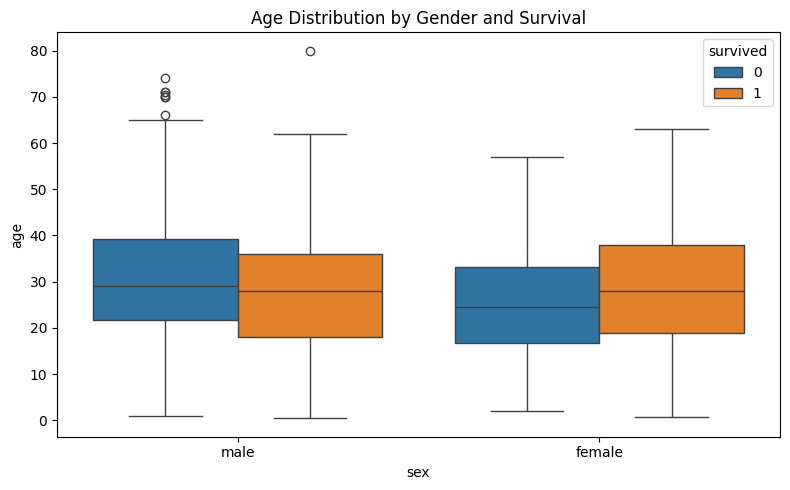

male Median Age: 29.0
female Median Age: 27.0


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")

plt.figure(figsize=(8, 5))
sns.boxplot(x="sex", y="age", hue="survived", data=df)
plt.title("Age Distribution by Gender and Survival")
plt.tight_layout()
plt.show()

for gender in ["male", "female"]:
    subset = df[df["sex"] == gender]["age"].dropna()
    median_age = subset.median()
    print(f"{gender} Median Age:", median_age)

---
## Practical 10: Data Visualization III (Iris — Histograms & Boxplots)

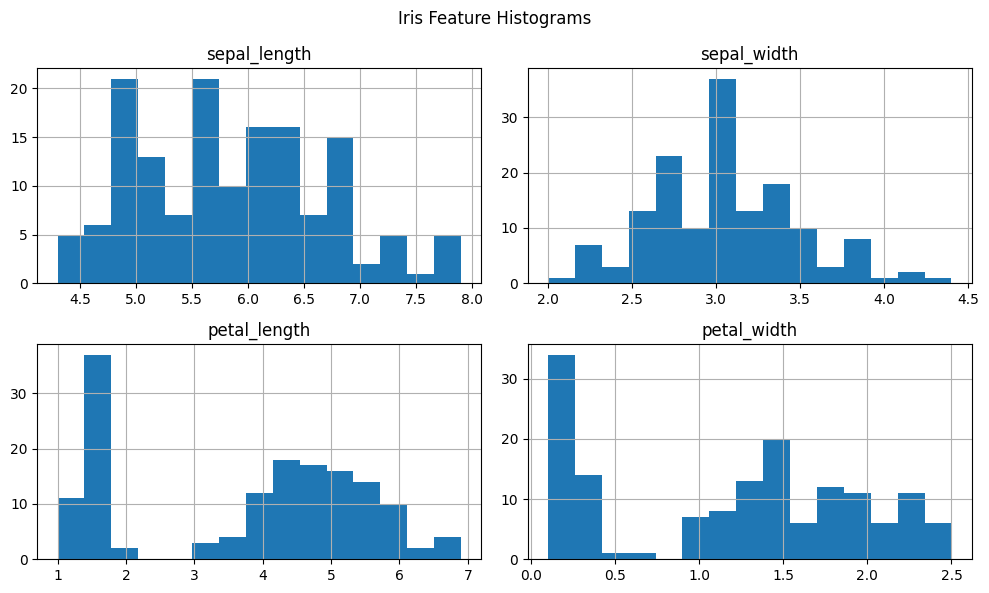

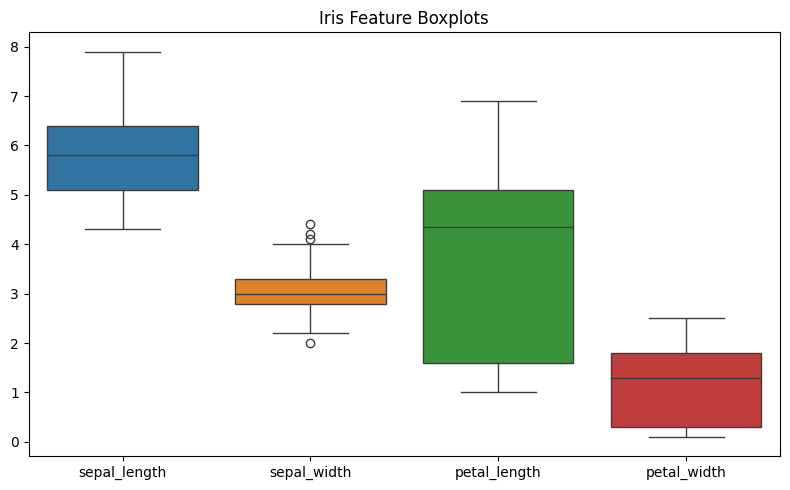

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("iris")

df.hist(figsize=(10, 6), bins=15)
plt.suptitle("Iris Feature Histograms")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df.drop("species", axis=1))
plt.title("Iris Feature Boxplots")
plt.tight_layout()
plt.show()

---
## Practical 11: MapReduce — Word Count

In [10]:
from collections import defaultdict

def mapper(text):
    return [(word.lower(), 1) for word in text.split()]

def reducer(pairs):
    counts = defaultdict(int)
    for word, count in pairs:
        counts[word] += count
    return dict(counts)

text = "Hadoop is simple Hadoop is powerful map reduce in hadoop"

mapped = mapper(text)
result = reducer(mapped)

for word, count in sorted(result.items()):
    print(f"{word:<10}{count}")

hadoop    3
in        1
is        2
map       1
powerful  1
reduce    1
simple    1


---
## Practical 12: MapReduce — Log Analysis

In [11]:
from collections import defaultdict

def log_mapper(line):
    level = line.split()[0]
    return [(level, 1)]

def log_reducer(pairs):
    counts = defaultdict(int)
    for level, count in pairs:
        counts[level] += count
    return dict(counts)

logs = [
    "INFO System started",
    "ERROR Disk failure",
    "WARN Memory low",
    "INFO User login",
    "ERROR Database failed"
]

all_pairs = []
for line in logs:
    all_pairs.extend(log_mapper(line))

result = log_reducer(all_pairs)

for level, count in sorted(result.items()):
    print(f"{level:<8} {count}")

ERROR    2
INFO     2
WARN     1


---
## Practical 13: MapReduce — Weather Analysis

In [ ]:
from collections import defaultdict

def weather_mapper(line):
    parts = line.split()
    return [
        ('Temperature', float(parts[1])),
        ('DewPoint',    float(parts[2])),
        ('WindSpeed',   float(parts[3]))
    ]

def weather_reducer(pairs):
    sums = defaultdict(list)
    for param, val in pairs:
        sums[param].append(val)
    return {k: sum(v) / len(v) for k, v in sums.items()}

weather = [
    "2024-01-01 25 18 12",
    "2024-01-02 28 20 10",
    "2024-01-03 30 22 15"
]

all_pairs = []
for line in weather:
    all_pairs.extend(weather_mapper(line))

result = weather_reducer(all_pairs)

print("Averages:")
for param, avg in result.items():
    print(f"{param:<12} {avg:.2f}")

Averages:
Temperature  27.67
DewPoint     20.00
WindSpeed    12.33
